# Clustering Analysis

Comobinaciones a tener en cuenta:

- Datos:
  
  1. scores discursivos --> Nuestras propuestas
  2. embeddings
  3. 1. + 2.
  3. 1. + scores reddit
  4. 3. + scores reddit

- Modelos:

  I. Nuestras propuestas --> (Fold) Fast Kmedoids con 1., 3., 4. y 5.
  II. Propuesta clásica --> KMeans con 2.


In [28]:
import os, sys
import polars as pl
from db_robust_clust.models import SampleDistClustering, FoldSampleDistClustering
from db_robust_clust.plots import clustering_MDS_plot_one_method
from kmedoids import KMedoids
from sklearn.manifold import MDS

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.data_analysis_utils import (
    plot_quant_comparison,
    plot_cat_comparison
)

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

In [ ]:
KMEDOIDS_METHOD = 'pam'
METRIC = 'ggower'
D1 = 'robust_mahalanobis'
D2 = 'sokal'
D3 = 'hamming'

FRAC_SAMPLE_SIZE = 0.15
N_SPLITS = 5

clust_objects = {}


## Clustering I: Data - Discursive Scores

In [ ]:
numerical_cols = [
    'sentiment_score'
]

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols + ordinal_cols
binary_cols = []
multiclass_cols = nominal_cols 

p1 = len(quant_cols)
p2 = len(binary_cols)
p3 = len(multiclass_cols)

X = processed_data[quant_cols + binary_cols + multiclass_cols]

In [ ]:
n_clusters_list = [2, 3, 4, 5]

for n_clusters in n_clusters_list:

    case_title = f'SampleDistClustering-KMedoids-PAM - k={n_clusters}'

    print('=')
    print(case_title)

    clustering_method = KMedoids(
        n_clusters=n_clusters, 
        metric='precomputed', 
        method=KMEDOIDS_METHOD, 
        init='build', 
        max_iter=100, 
        random_state=123
    )

    clust_object = SampleDistClustering(
        clustering_method = clustering_method,
        metric = METRIC,
        frac_sample_size=FRAC_SAMPLE_SIZE,
        random_state=123,
        stratify=False,
        p1=p1, p2=p2, p3=p3,
        d1=D1, d2=D2, d3=D3, 
        robust_method='trimmed', alpha=0.05
    )

    clust_object.fit(X)

    clust_labels = clust_object.labels_


    ##################################################################################################

    D, D1, D2, D3 = clust_object.dist_output
    sample_idx = clust_object.sample_idx

    n_reduced = 1000

    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=123) 

    X_mds = mds.fit_transform(D[:n_reduced, :n_reduced])

    clustering_MDS_plot_one_method(X_mds=X_mds, 
                                y_pred=clust_labels[sample_idx[:n_reduced]], 
                                y_true=None, title="MDS visualization of clustering results", 
                                accuracy=None, time=None, 
                                figsize=(8,7), bbox_to_anchor=(1,1), 
                                title_size=13, title_weight='bold', 
                                points_size=45, title_height=1, 
                                save=False, legend_size=9)
    
    ##################################################################################################

    plot_quant_comparison(
        figsize=(12, 4),
        df=processed_data,
        comparisons=[
            ['political_stance_score'], ['argument_quality_score'], ['sentiment_score']
        ],
        group_by="labels('sample_dist_clust', 'n_clusters=3')",
        showfliers=True,
        title='',
        labelbottom=True,
        xlabel_rotation=0,
        bbox_to_anchor=(0.5, -0.12)
    )


    ##################################################################################################

    plot_cat_comparison(
        df=processed_data, 
        comparisons=[
            ['discourse_tone_score_label'], ['dominant_frame_score_label'], ['argument_quality_score_label'], ['sentiment_score_label'], ['political_stance_score_label']
        ], 
        title="",
        bbox_to_anchor=(0.5,-0.1),
        group_by="labels('sample_dist_clust', 'n_clusters=3')",
        max_cols=3,
        #x_rotation
        #orientation
    )

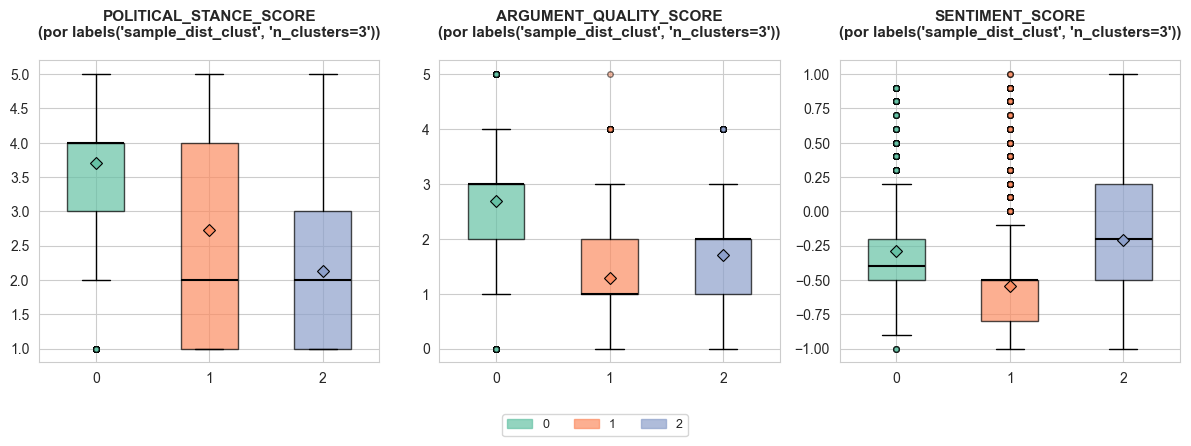

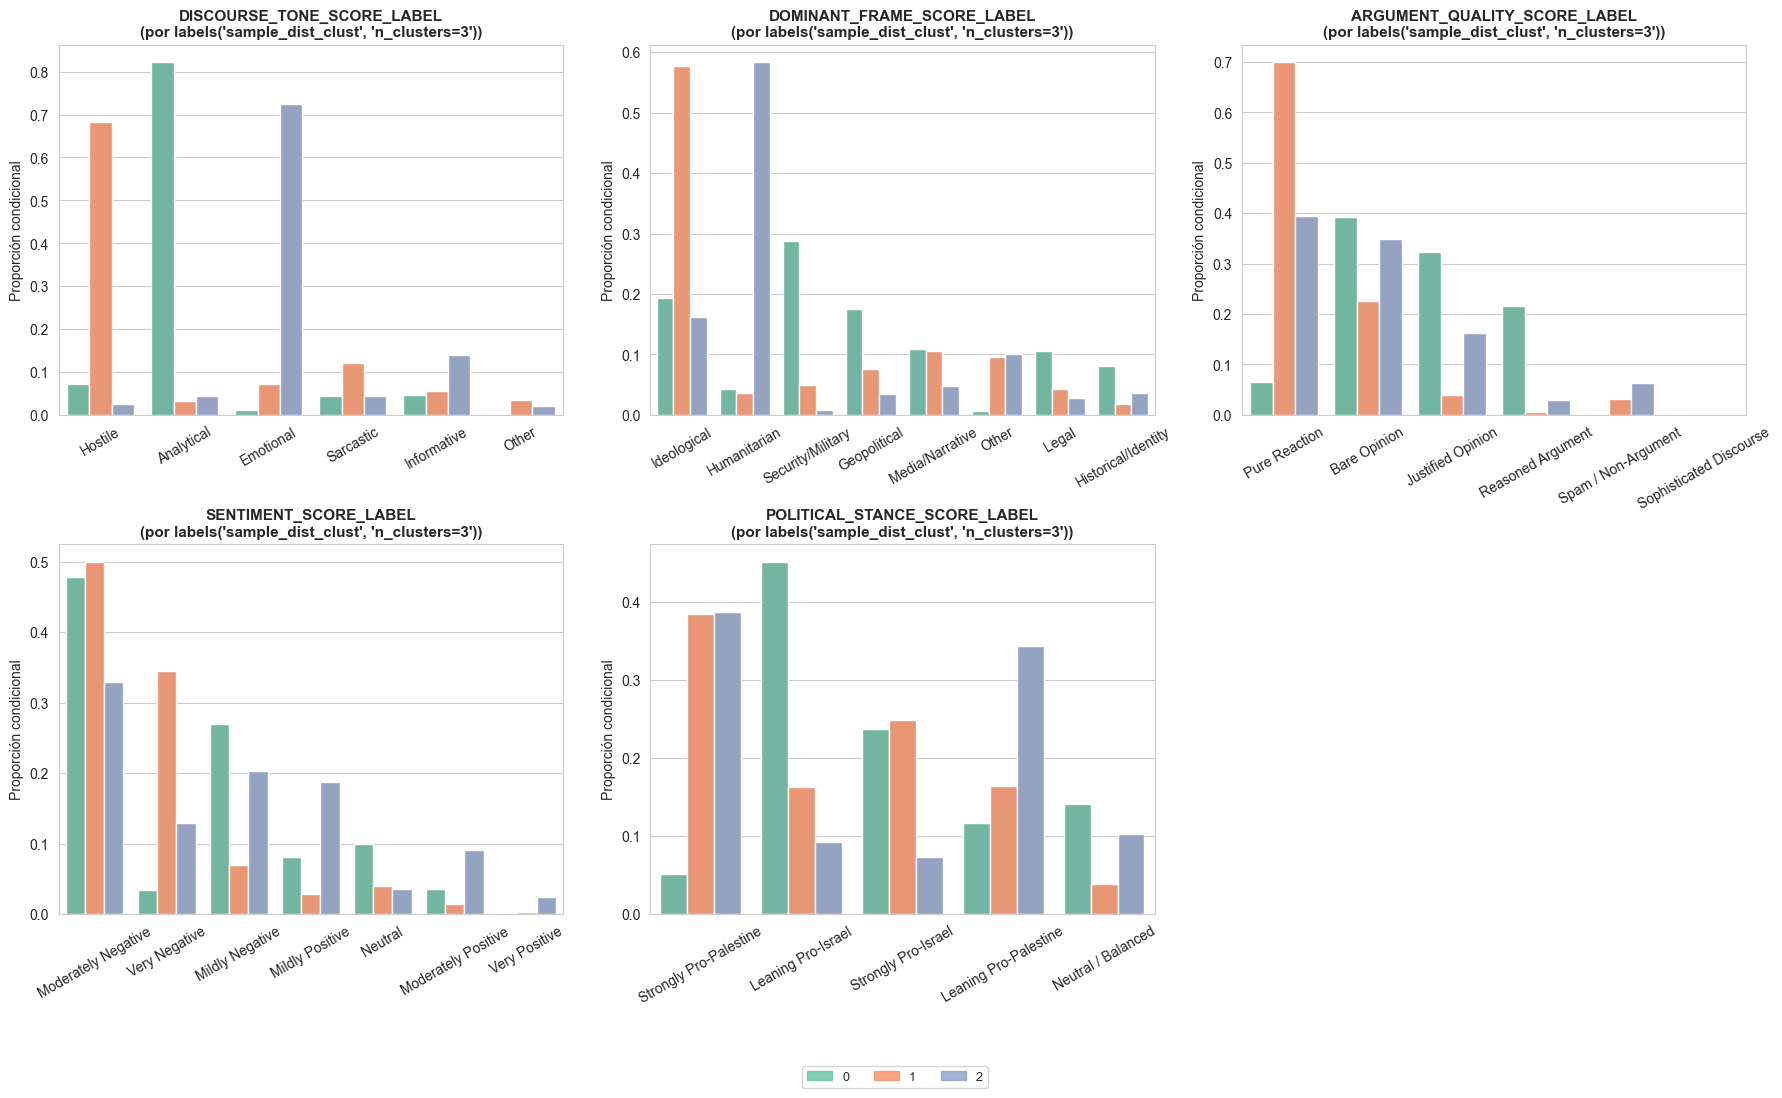